In [161]:
# STEP 2: Import libraries
import os
import zipfile
import cv2
from skimage.feature import hog
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [162]:

zip_path = "/content/archive (1).zip"
extract_path = "/content/extracted_dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [163]:
print(os.listdir(extract_path))

['fruit-dataset']


In [164]:
print(os.listdir(extract_path + "/fruit-dataset"))

['apple', 'orange']


In [165]:
print(os.listdir(extract_path+"/fruit-dataset"+"/apple"))

['299.jpeg', '279.jpeg', '111.jpeg', '003.jpeg', '217.jpeg', '277.jpeg', '230.jpeg', '323.jpeg', '093.jpeg', '098.jpeg', '260.jpeg', '370.jpeg', '053.jpeg', '337.jpeg', '106.jpeg', '183.jpeg', '254.jpeg', '244.jpeg', '160.jpeg', '130.jpeg', '374.jpeg', '207.jpeg', '296.jpeg', '118.jpeg', '152.jpeg', '027.jpeg', '095.jpeg', '075.jpeg', '051.jpeg', '088.jpeg', '039.jpeg', '060.jpeg', '064.jpeg', '.ipynb_checkpoints', '295.jpeg', '178.jpeg', '090.jpeg', '094.jpeg', '192.jpeg', '365.jpeg', '041.jpeg', '042.jpeg', '220.jpeg', '050.jpeg', '036.jpeg', '002.jpeg', '284.jpeg', '187.jpeg', '157.jpeg', '232.jpeg', '271.jpeg', '007.jpeg', '251.jpeg', '214.jpeg', '368.jpeg', '397.jpeg', '275.jpeg', '366.jpeg', '067.jpeg', '038.jpeg', '092.jpeg', '018.jpeg', '005.jpeg', '185.jpeg', '197.jpeg', '314.jpeg', '328.jpeg', '361.jpeg', '227.jpeg', '159.jpeg', '161.jpeg', '044.jpeg', '360.jpeg', '381.jpeg', '165.jpeg', '142.jpeg', '089.jpeg', '398.jpeg', '167.jpeg', '013.jpeg', '342.jpeg', '394.jpeg', '076.

In [166]:
def preprocess(img):
    img = cv2.resize(img, (128,128))
    # if np.random.rand() > 0.5:
    #     img = cv2.flip(img, 1)  # flip
    # img = cv2.convertScaleAbs(  # brightness and contrast
    #     img,
    #     alpha=np.random.uniform(0.8,1.2),
    #     beta=np.random.randint(-30,30)
    # )
    # angle = np.random.randint(-20,20)  # rotation
    # h, w = img.shape[:2]
    # matrix = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    # img1 = cv2.warpAffine(img, matrix, (w,h))
    # img2 = cv2.GaussianBlur(img, (3,3), 0)  # gaussian filtering
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    return img, hsv, gray

In [167]:
def extract_features(img, hsv, gray):
    features = []

    # 1. HSV Hue Histogram
    hist = cv2.calcHist([hsv], [0], None, [32], [0, 180])
    hist = hist.astype("float32")
    hist /= (hist.sum() + 1e-6)
    features.extend(hist.flatten())

    # 2. Texture (LBP)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))
    lbp_hist = lbp_hist.astype("float32")
    lbp_hist /= (lbp_hist.sum() + 1e-6)
    features.extend(lbp_hist)

    # 3. Shape Features (SAFE)
    edges = cv2.Canny(gray, 100, 200)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area = sum(cv2.contourArea(c) for c in contours)
    perimeter = sum(cv2.arcLength(c, True) for c in contours)

    # Hard safety guards
    area = np.clip(area, 0, 1e5)
    perimeter = np.clip(perimeter, 0, 1e4)

    circularity = (4 * np.pi * area) / (perimeter**2 + 1e-6)

    features.extend([area, perimeter, circularity])

        # 3. HOG Features
    # hog_features = hog(
    #     gray,
    #     orientations=9,
    #     pixels_per_cell=(8,8),
    #     cells_per_block=(2,2),
    #     visualize=False,
    #     feature_vector=True
    # )
    # hog_features = hog_features.astype("float32")
    # features.extend(hog_features)
    return np.array(features, dtype=np.float32)

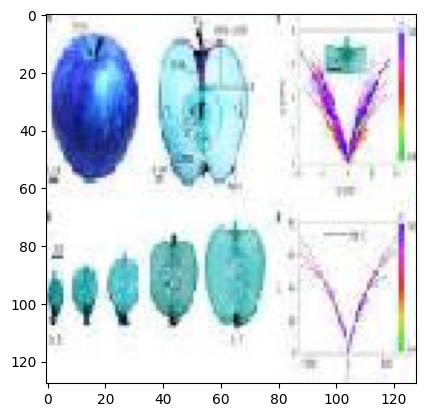

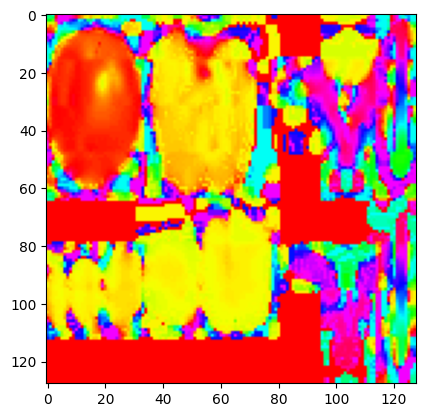

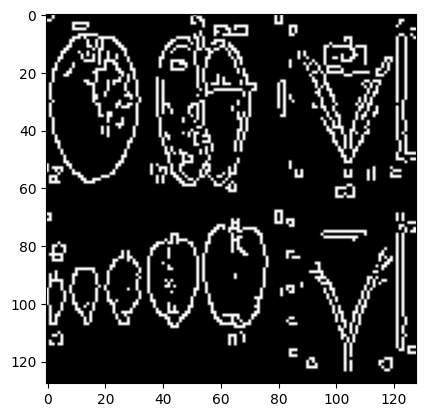

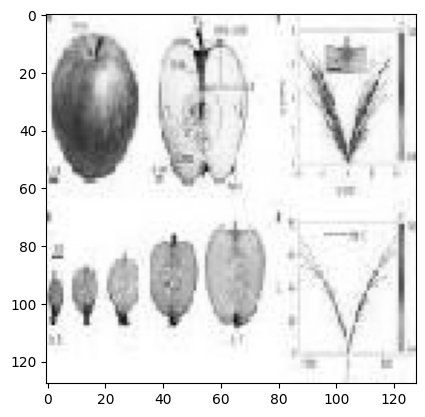

In [182]:
img=cv2.imread('/content/extracted_dataset/fruit-dataset/apple/360.jpeg')
img,hsv,gray=preprocess(img)
edge=cv2.Canny(gray,150,200)
plt.imshow(img)
plt.show()
plt.imshow(hsv[:,:,0],cmap='hsv')
plt.show()
plt.imshow(edge,cmap='gray')
plt.show()
plt.imshow(gray,cmap='gray')
plt.show()


In [169]:
X=[]
y=[]
base_path='/content/extracted_dataset/fruit-dataset/apple'

for i in os.listdir(base_path):
    try:
        path=os.path.join(base_path,i)
        img=cv2.imread(path)
        img,hsv,gray=preprocess(img)
        features=extract_features(img,hsv,gray)
        X.append(features)
        y.append(0)
    except Exception as e:
        print(e,end='\r')
print()
base_path='/content/extracted_dataset/fruit-dataset/orange'

for i in os.listdir(base_path):
    try:
        path=os.path.join(base_path,i)
        img=cv2.imread(path)
        img,hsv,gray=preprocess(img)
        features=extract_features(img,hsv,gray)
        X.append(features)
        y.append(1)
    except Exception as e:
        print(e,end='\r')

OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'



In [170]:
X=np.array(X,dtype='float32')
y=np.array(y)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [171]:
import sklearn

In [172]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled,y_resampled, test_size = 0.2, random_state=42, stratify=y_resampled)

In [173]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [174]:
clf = SVC(kernel='linear')
clf.fit(X_train, y_train)

SVC(kernel='linear')

In [185]:
clf = RandomForestClassifier(n_estimators=100,random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# model = LogisticRegression( C=1.0,max_iter=1000, random_state=42)
# model.fit(X_train, y_train)
# model = DecisionTreeClassifier(max_depth=5,min_samples_split=2,random_state=42)
# model.fit(X_train, y_train)
# model = GaussianNB()
# model.fit(X_train, y_train)
# model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1)
# model.fit(X_train, y_train)
# model = ExtraTreesClassifier(n_estimators=100,max_depth=5)
# model.fit(X_train, y_train)
# model = KNeighborsClassifier(n_neighbors=5)
# model.fit(X_train, y_train)
# model = XGBClassifier(n_estimators=100,learning_rate=0.1)
# model.fit(X_train, y_train)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

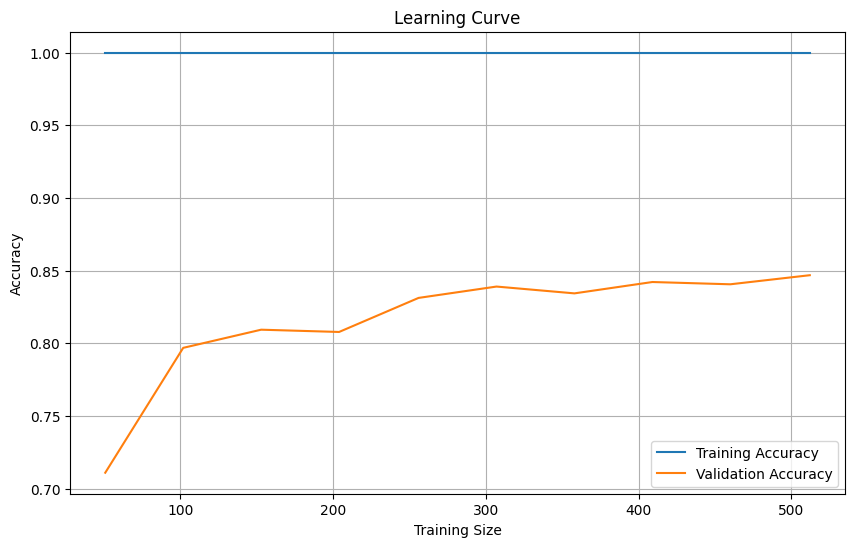

In [176]:
train_sizes, train_scores, test_scores = learning_curve(
    clf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10,6))

plt.plot(train_sizes, train_mean, label='Training Accuracy')

plt.plot(train_sizes, test_mean, label='Validation Accuracy')

plt.xlabel('Training Size')

plt.ylabel('Accuracy')

plt.title('Learning Curve')

plt.legend()

plt.grid()

plt.show()

In [186]:
y_pred = clf.predict(X_test)

classes = ["apple", "orange"]

# Classification Report
print(classification_report(y_test, y_pred, target_names=classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

              precision    recall  f1-score   support

       apple       0.85      0.94      0.89        80
      orange       0.93      0.84      0.88        80

    accuracy                           0.89       160
   macro avg       0.89      0.89      0.89       160
weighted avg       0.89      0.89      0.89       160

Accuracy: 88.75%


In [178]:
predicted_labels = [classes[i] for i in y_pred]

actual_labels = [classes[i] for i in y_test]

In [179]:
results = pd.DataFrame({
    'Actual': actual_labels,
    'Predicted': predicted_labels
})

results.to_csv('classification_results.csv', index=False)

print(results.head())

   Actual Predicted
0  orange     apple
1   apple     apple
2   apple     apple
3  orange    orange
4  orange    orange


In [180]:
import requests
import json
url="https://raw.githubusercontent.com/Dhruv-coder797/cvese/main/final.ipynb"
content=requests.get(url).json()
for i,cell in enumerate(content["cells"]):
  print("".join(cell["source"]))

# STEP 2: Import libraries
import os
import zipfile
import cv2
from skimage.feature import hog
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

zip_path = "/content/archive (1).zip"
extract_path = "/content/extracted_dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref